In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc

# reproducibilidad
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

#Funciones del TP5
from Bio import SeqIO

def load_fasta(path):
    return [str(record.seq) for record in SeqIO.parse(path, "fasta")]

def pad_or_trim(seq, max_len=100):
    if len(seq) > max_len:
        return seq[:max_len]
    else:
        return seq + 'N'*(max_len - len(seq))

def one_hot_encode(seq):
    mapping = {'A':0, 'C':1, 'G':2, 'T':3}
    ohe = np.zeros((4, len(seq)))

    for i, base in enumerate(seq):
        if base in mapping:
            ohe[mapping[base], i] = 1

    return ohe

def encode_dataset(seqs):
    return np.array([one_hot_encode(s) for s in seqs])

#Split (TP6)
def split_data(positives, negatives, test_size=61):

    idx = np.random.permutation(len(positives))

    pos_test = [positives[i] for i in idx[:test_size]]
    pos_train = [positives[i] for i in idx[test_size:]]

    neg_sample = random.sample(negatives, len(positives))

    neg_test = neg_sample[:test_size]
    neg_train = neg_sample[test_size:test_size+len(pos_train)]

    return pos_train, pos_test, neg_train, neg_test

# cargar datos 
positives = load_fasta("../sequences_upper.fasta")
positives = [pad_or_trim(s, 100) for s in positives]

#Generamos negatinos (Del TP5)
#N1 - Random 
import random

def random_dna(length):
    return ''.join(random.choices(['A','C','G','T'], k=length))

neg_N1 = [random_dna(len(seq)) for seq in positives]
#N2 - shuffle
def shuffle_seq(seq):
    seq_list = list(seq)
    random.shuffle(seq_list)
    return ''.join(seq_list)

neg_N2 = [shuffle_seq(seq) for seq in positives]
#N3 - Negativos más realistas
neg_N3 = []

for seq in positives:
    mutated = list(seq)
    for i in range(len(mutated)):
        if random.random() < 0.1:  # 10% mutación
            mutated[i] = random.choice(['A','C','G','T'])
    neg_N3.append(''.join(mutated))

negatives = neg_N1 + neg_N2 + neg_N3  # del TP5
random.shuffle(negatives)

# opcional: limitar tamaño
negatives = negatives[:len(positives)*2]
print("Positives:", len(positives))
print("Negatives:", len(negatives))


Positives: 561
Negatives: 1122


### Generación de negativos

Se generaron tres tipos de secuencias negativas:

- Aleatorias (N1)
- Secuencias shuffleadas (N2)
- Secuencias con mutaciones (~10%) (N3)

Esto permite evaluar el modelo frente a distintos niveles de dificultad y evita soluciones triviales basadas en composición de nucleótidos.

In [2]:
# split
pos_train, pos_test, neg_train, neg_test = split_data(positives, negatives)

# encoding
X_train = np.concatenate([encode_dataset(pos_train), encode_dataset(neg_train)])
y_train = np.concatenate([np.ones(len(pos_train)), np.zeros(len(neg_train))])

X_test = np.concatenate([encode_dataset(pos_test), encode_dataset(neg_test)])
y_test = np.concatenate([np.ones(len(pos_test)), np.zeros(len(neg_test))])

#Dataloader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
print("Train positives:", len(pos_train))
print("Train negatives:", len(neg_train))
print("Test positives:", len(pos_test))
print("Test negatives:", len(neg_test))

Train positives: 500
Train negatives: 500
Test positives: 61
Test negatives: 61


In [3]:
#Iniciar modelo
class DNA_CNN(nn.Module):
    def __init__(self, seq_len=100, num_filters=8, kernel_size=5):
        super().__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)

        conv_output_len = seq_len - kernel_size + 1
        self.fc1 = nn.Linear(num_filters * conv_output_len, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

In [4]:
#Entrenar
def train_model(model, train_loader, test_loader, epochs=30):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X).squeeze()
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # evaluación
        model.eval()
        total_loss = 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out = model(X).squeeze()
                loss = criterion(out, y)
                total_loss += loss.item()

        test_losses.append(total_loss / len(test_loader))
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, test={test_losses[-1]:.4f}")
    return train_losses, test_losses

In [5]:
#Métricas
def evaluate_model(model, loader):

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X).squeeze()
            probs = torch.sigmoid(out).cpu().numpy()

            y_pred.extend(probs)
            y_true.extend(y.cpu().numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    acc = accuracy_score(y_true, y_pred > 0.5)
    roc = roc_auc_score(y_true, y_pred)

    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    pr_auc = auc(recall, precision)

    return acc, roc, pr_auc

In [6]:
#Plot loss
def plot_losses(train_losses, test_losses, name):

    plt.figure()
    plt.plot(train_losses, label="train")
    plt.plot(test_losses, label="test")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

     # guardar
    path = f"{RESULTS_DIR}/{name}_loss.png"
    plt.savefig(path)

    print(f"Gráfico guardado en: {path}")

    # mostrar en notebook
    plt.show()

Epoch 5: train=0.6586, test=0.7021
Epoch 10: train=0.6008, test=0.7123
Epoch 15: train=0.5524, test=0.7185
Epoch 20: train=0.5136, test=0.7303
Epoch 25: train=0.4861, test=0.7465
Epoch 30: train=0.4540, test=0.7729
Gráfico guardado en: ../results/baseline_loss.png


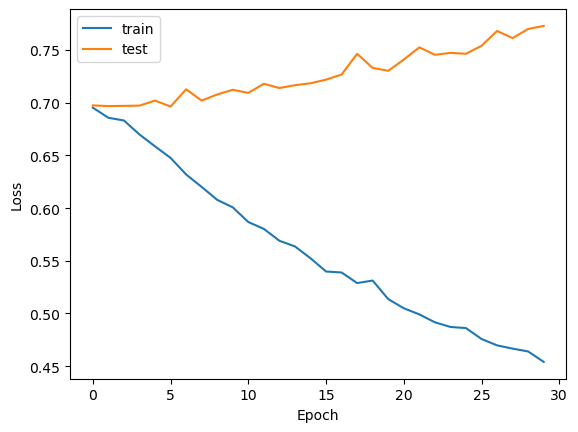

In [7]:
#Ejecutar modelo baseline

model = DNA_CNN(seq_len=100, num_filters=8, kernel_size=5).to(device)

train_losses, test_losses = train_model(
    model,
    train_loader,
    test_loader,
    epochs=30
)

plot_losses(train_losses, test_losses, "baseline")

### Análisis de overfitting

Se observa que la loss del conjunto de entrenamiento disminuye de forma sostenida a lo largo de las épocas, indicando que el modelo logra ajustarse cada vez mejor a los datos de entrenamiento.

Sin embargo, la loss del conjunto de test aumenta progresivamente desde las primeras épocas, lo que indica que el modelo no logra generalizar adecuadamente a datos no vistos.

Este comportamiento evidencia un caso de overfitting fuerte y temprano, donde el modelo comienza a memorizar el conjunto de entrenamiento sin mejorar su capacidad predictiva sobre el conjunto de test.

Este comportamiento sugiere que incluso una arquitectura relativamente simple (8 filtros, kernel de tamaño 5) posee suficiente capacidad para sobreajustar el dataset, lo que motiva la necesidad de aplicar técnicas de regularización.


Entrenando modelo: kernels=2, kernel_size=3
Epoch 5: train=0.6841, test=0.6908
Epoch 10: train=0.6703, test=0.6887
Epoch 15: train=0.6576, test=0.6979
Epoch 20: train=0.6487, test=0.6990
Epoch 25: train=0.6322, test=0.7068
Epoch 30: train=0.6280, test=0.7171
Gráfico guardado en: ../results/k2_ks3_loss.png


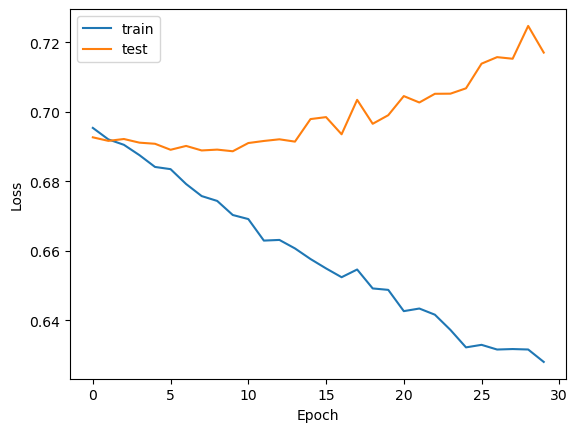


Entrenando modelo: kernels=2, kernel_size=6
Epoch 5: train=0.6857, test=0.6895
Epoch 10: train=0.6751, test=0.6887
Epoch 15: train=0.6663, test=0.6874
Epoch 20: train=0.6480, test=0.6937
Epoch 25: train=0.6358, test=0.6984
Epoch 30: train=0.6308, test=0.7068
Gráfico guardado en: ../results/k2_ks6_loss.png


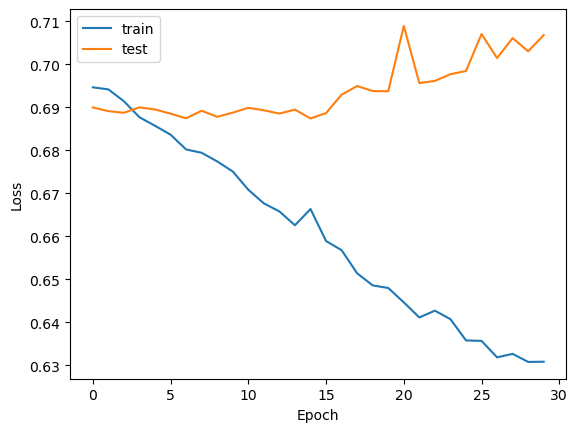


Entrenando modelo: kernels=2, kernel_size=10
Epoch 5: train=0.6914, test=0.6952
Epoch 10: train=0.6717, test=0.6914
Epoch 15: train=0.6427, test=0.6941
Epoch 20: train=0.6296, test=0.7031
Epoch 25: train=0.6092, test=0.7161
Epoch 30: train=0.5942, test=0.7439
Gráfico guardado en: ../results/k2_ks10_loss.png


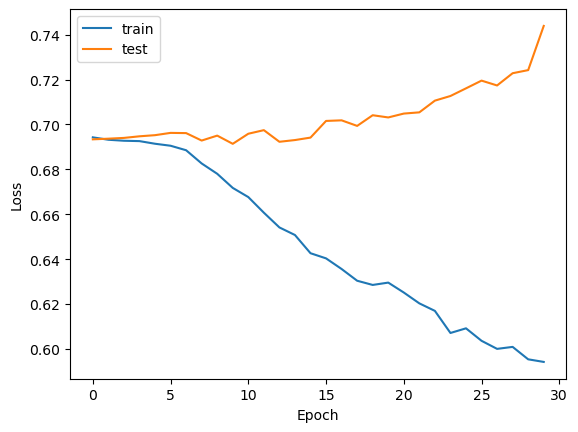


Entrenando modelo: kernels=2, kernel_size=15
Epoch 5: train=0.6882, test=0.6982
Epoch 10: train=0.6715, test=0.7008
Epoch 15: train=0.6528, test=0.7065
Epoch 20: train=0.6381, test=0.7134
Epoch 25: train=0.6212, test=0.7230
Epoch 30: train=0.6154, test=0.7307
Gráfico guardado en: ../results/k2_ks15_loss.png


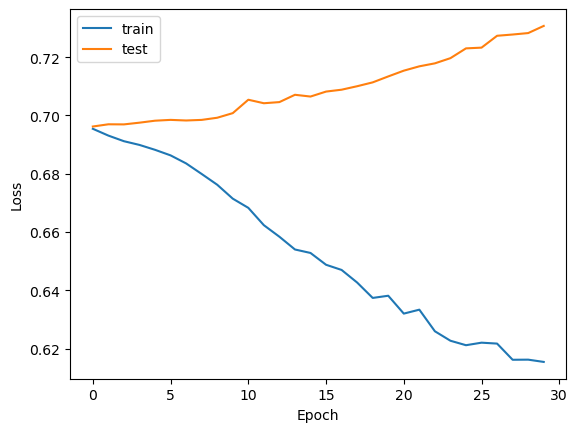


Entrenando modelo: kernels=2, kernel_size=20
Epoch 5: train=0.6840, test=0.6996
Epoch 10: train=0.6641, test=0.7082
Epoch 15: train=0.6427, test=0.7218
Epoch 20: train=0.6216, test=0.7370
Epoch 25: train=0.6194, test=0.7649
Epoch 30: train=0.6038, test=0.7726
Gráfico guardado en: ../results/k2_ks20_loss.png


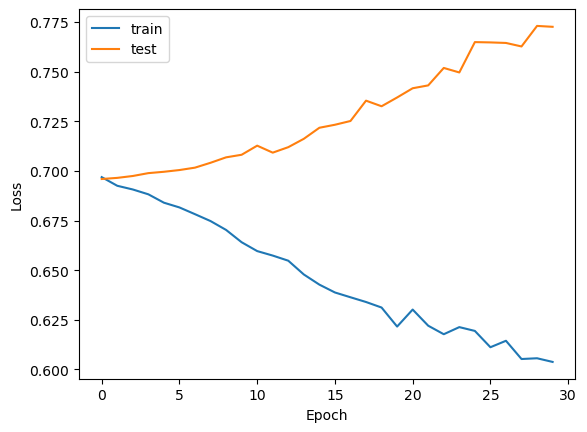


Entrenando modelo: kernels=4, kernel_size=3
Epoch 5: train=0.6802, test=0.6974
Epoch 10: train=0.6507, test=0.7030
Epoch 15: train=0.6163, test=0.7182
Epoch 20: train=0.5895, test=0.7366
Epoch 25: train=0.5644, test=0.7459
Epoch 30: train=0.5423, test=0.7671
Gráfico guardado en: ../results/k4_ks3_loss.png


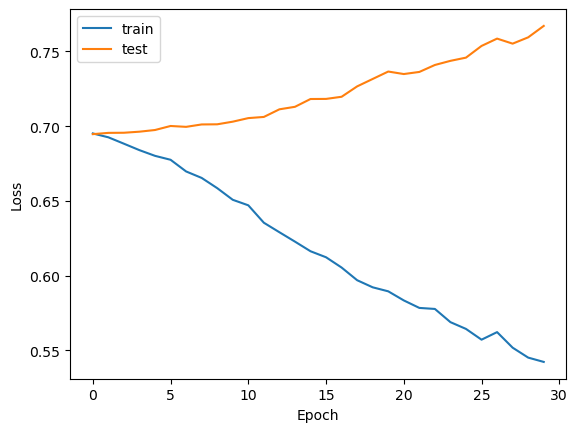


Entrenando modelo: kernels=4, kernel_size=6
Epoch 5: train=0.6664, test=0.6946
Epoch 10: train=0.6296, test=0.6978
Epoch 15: train=0.5974, test=0.6993
Epoch 20: train=0.5657, test=0.7170
Epoch 25: train=0.5400, test=0.7299
Epoch 30: train=0.5175, test=0.7325
Gráfico guardado en: ../results/k4_ks6_loss.png


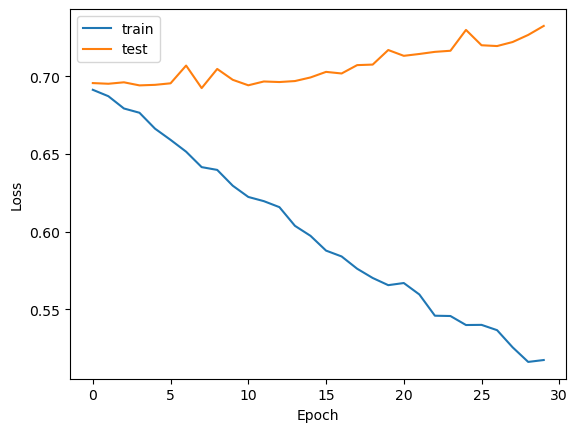


Entrenando modelo: kernels=4, kernel_size=10
Epoch 5: train=0.6734, test=0.6866
Epoch 10: train=0.6362, test=0.6857
Epoch 15: train=0.6097, test=0.6937
Epoch 20: train=0.5669, test=0.7059
Epoch 25: train=0.5415, test=0.7457
Epoch 30: train=0.5142, test=0.7418
Gráfico guardado en: ../results/k4_ks10_loss.png


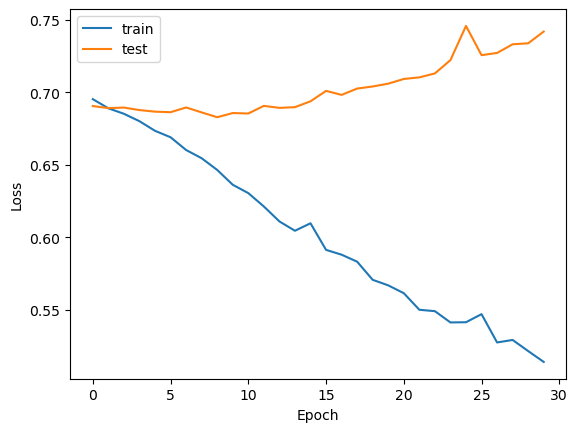


Entrenando modelo: kernels=4, kernel_size=15
Epoch 5: train=0.6754, test=0.7014
Epoch 10: train=0.6466, test=0.7119
Epoch 15: train=0.6205, test=0.7345
Epoch 20: train=0.6018, test=0.7712
Epoch 25: train=0.5842, test=0.7798
Epoch 30: train=0.5682, test=0.8010
Gráfico guardado en: ../results/k4_ks15_loss.png


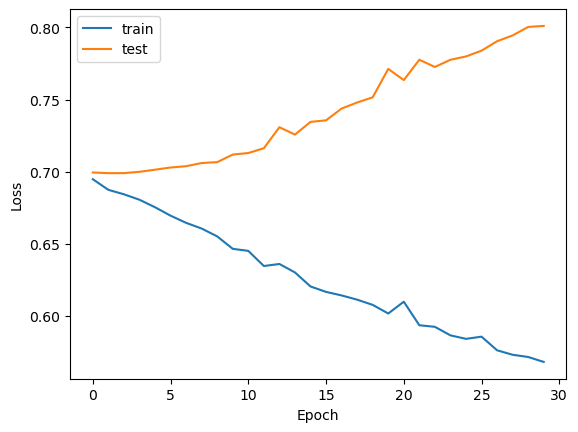


Entrenando modelo: kernels=4, kernel_size=20
Epoch 5: train=0.6724, test=0.7017
Epoch 10: train=0.6401, test=0.7146
Epoch 15: train=0.6051, test=0.7412
Epoch 20: train=0.5817, test=0.7635
Epoch 25: train=0.5616, test=0.7862
Epoch 30: train=0.5452, test=0.8122
Gráfico guardado en: ../results/k4_ks20_loss.png


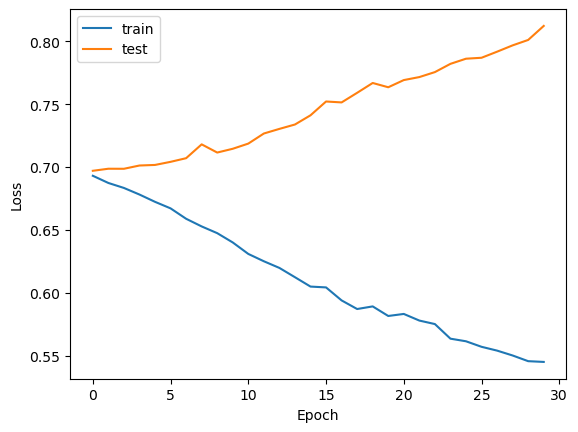


Entrenando modelo: kernels=8, kernel_size=3
Epoch 5: train=0.6657, test=0.6983
Epoch 10: train=0.6189, test=0.7098
Epoch 15: train=0.5861, test=0.7270
Epoch 20: train=0.5425, test=0.7431
Epoch 25: train=0.5174, test=0.7600
Epoch 30: train=0.4802, test=0.7892
Gráfico guardado en: ../results/k8_ks3_loss.png


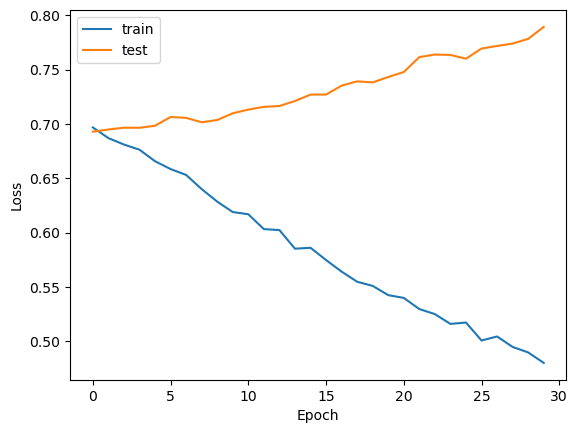


Entrenando modelo: kernels=8, kernel_size=6
Epoch 5: train=0.6663, test=0.6919
Epoch 10: train=0.6181, test=0.7072
Epoch 15: train=0.5732, test=0.7364
Epoch 20: train=0.5404, test=0.7575
Epoch 25: train=0.5205, test=0.7702
Epoch 30: train=0.4888, test=0.7911
Gráfico guardado en: ../results/k8_ks6_loss.png


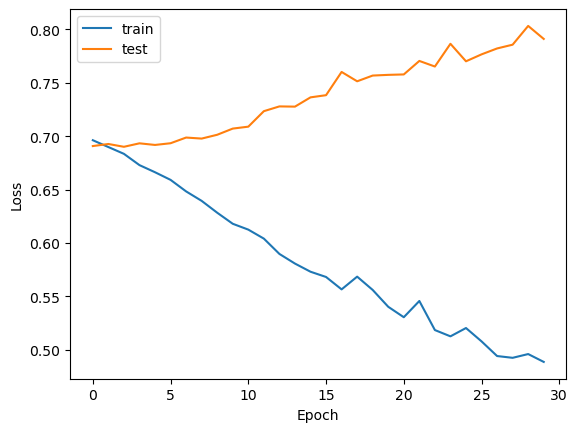


Entrenando modelo: kernels=8, kernel_size=10
Epoch 5: train=0.6637, test=0.6944
Epoch 10: train=0.6159, test=0.7155
Epoch 15: train=0.5862, test=0.7648
Epoch 20: train=0.5454, test=0.7438
Epoch 25: train=0.5153, test=0.7527
Epoch 30: train=0.4966, test=0.7593
Gráfico guardado en: ../results/k8_ks10_loss.png


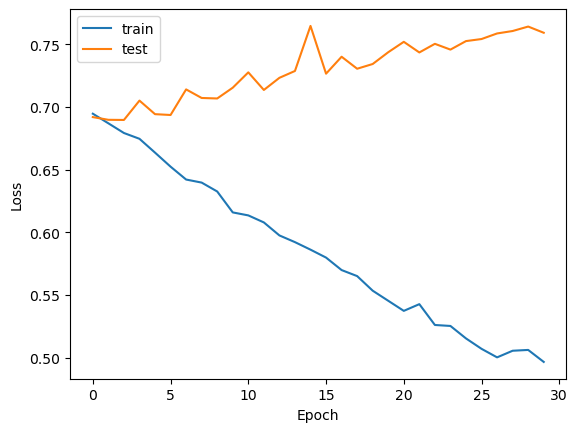


Entrenando modelo: kernels=8, kernel_size=15
Epoch 5: train=0.6682, test=0.7028
Epoch 10: train=0.6193, test=0.7156
Epoch 15: train=0.5721, test=0.7458
Epoch 20: train=0.5355, test=0.7772
Epoch 25: train=0.4954, test=0.8040
Epoch 30: train=0.4621, test=0.8375
Gráfico guardado en: ../results/k8_ks15_loss.png


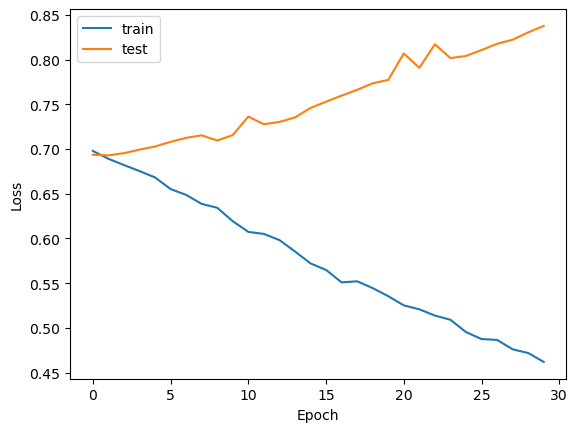


Entrenando modelo: kernels=8, kernel_size=20
Epoch 5: train=0.6643, test=0.6919
Epoch 10: train=0.6040, test=0.7122
Epoch 15: train=0.5604, test=0.7496
Epoch 20: train=0.5123, test=0.8060
Epoch 25: train=0.4909, test=0.8601
Epoch 30: train=0.4417, test=0.8641
Gráfico guardado en: ../results/k8_ks20_loss.png


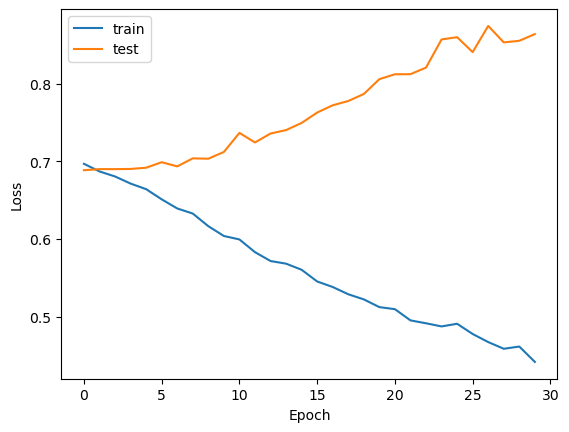


Entrenando modelo: kernels=16, kernel_size=3
Epoch 5: train=0.6533, test=0.7061
Epoch 10: train=0.5733, test=0.7048
Epoch 15: train=0.5142, test=0.7257
Epoch 20: train=0.4640, test=0.7574
Epoch 25: train=0.4253, test=0.7700
Epoch 30: train=0.3930, test=0.8049
Gráfico guardado en: ../results/k16_ks3_loss.png


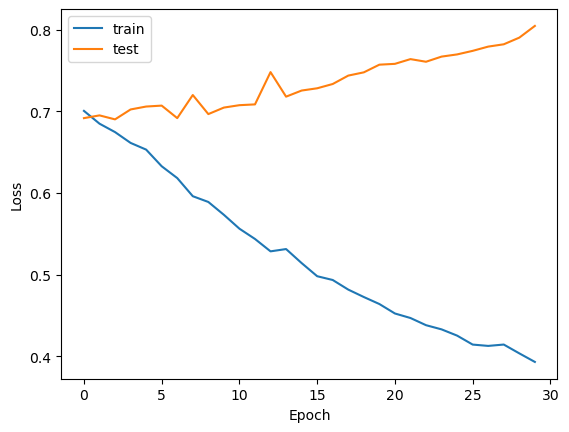


Entrenando modelo: kernels=16, kernel_size=6
Epoch 5: train=0.6446, test=0.6940
Epoch 10: train=0.5817, test=0.7262
Epoch 15: train=0.5208, test=0.7633
Epoch 20: train=0.4717, test=0.8152
Epoch 25: train=0.4193, test=0.8227
Epoch 30: train=0.3893, test=0.8520
Gráfico guardado en: ../results/k16_ks6_loss.png


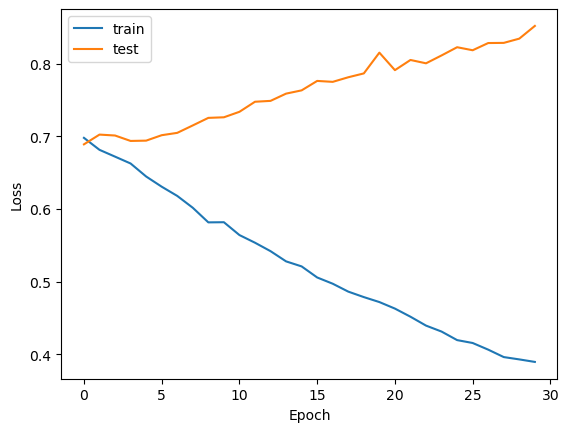


Entrenando modelo: kernels=16, kernel_size=10
Epoch 5: train=0.6389, test=0.7069
Epoch 10: train=0.5744, test=0.7494
Epoch 15: train=0.5115, test=0.7880
Epoch 20: train=0.4755, test=0.8182
Epoch 25: train=0.4415, test=0.8498
Epoch 30: train=0.4015, test=0.8772
Gráfico guardado en: ../results/k16_ks10_loss.png


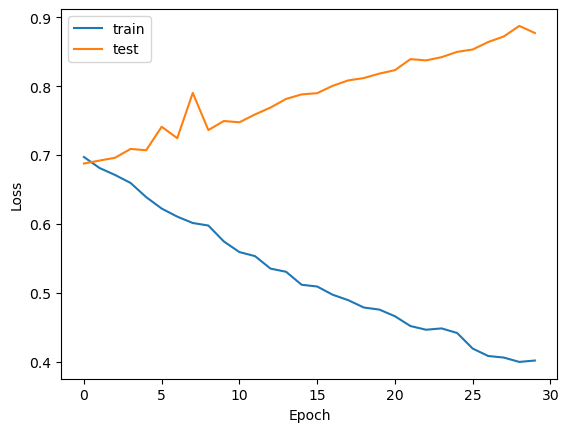


Entrenando modelo: kernels=16, kernel_size=15
Epoch 5: train=0.6360, test=0.7139
Epoch 10: train=0.5620, test=0.7552
Epoch 15: train=0.5031, test=0.7980
Epoch 20: train=0.4458, test=0.8475
Epoch 25: train=0.4002, test=0.8742
Epoch 30: train=0.3701, test=0.9186
Gráfico guardado en: ../results/k16_ks15_loss.png


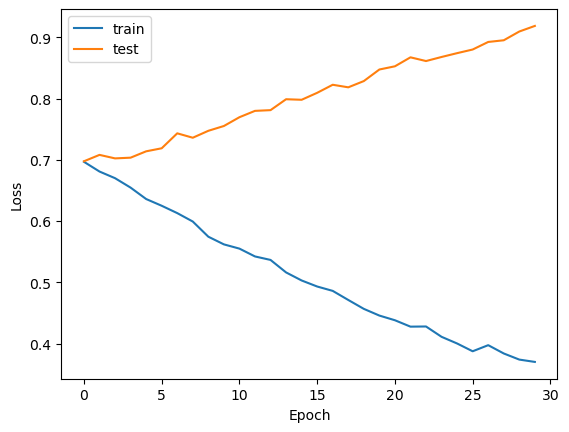


Entrenando modelo: kernels=16, kernel_size=20
Epoch 5: train=0.6409, test=0.7143
Epoch 10: train=0.5691, test=0.7851
Epoch 15: train=0.5213, test=0.8110
Epoch 20: train=0.4713, test=0.9223
Epoch 25: train=0.4149, test=0.9048
Epoch 30: train=0.3706, test=0.9510
Gráfico guardado en: ../results/k16_ks20_loss.png


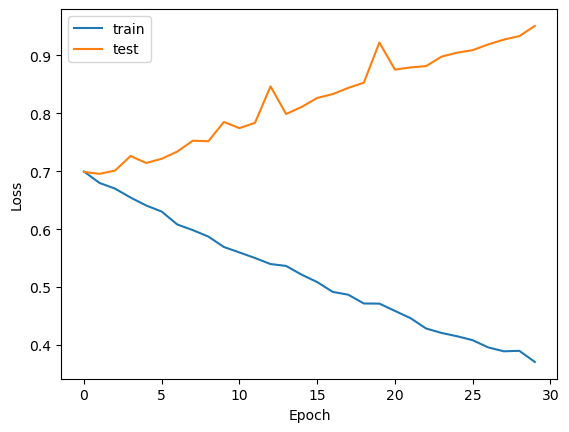


Entrenando modelo: kernels=24, kernel_size=3
Epoch 5: train=0.6234, test=0.7043
Epoch 10: train=0.5312, test=0.7464
Epoch 15: train=0.4619, test=0.7597
Epoch 20: train=0.4382, test=0.7971
Epoch 25: train=0.3819, test=0.8208
Epoch 30: train=0.3516, test=0.8596
Gráfico guardado en: ../results/k24_ks3_loss.png


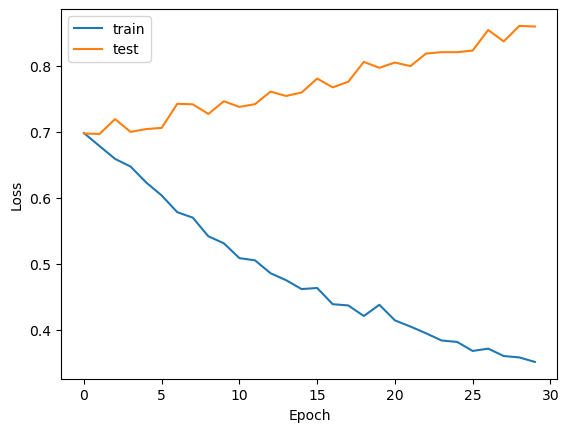


Entrenando modelo: kernels=24, kernel_size=6
Epoch 5: train=0.6234, test=0.7006
Epoch 10: train=0.5097, test=0.7172
Epoch 15: train=0.4528, test=0.7523
Epoch 20: train=0.3907, test=0.7948
Epoch 25: train=0.3598, test=0.8522
Epoch 30: train=0.3216, test=0.8795
Gráfico guardado en: ../results/k24_ks6_loss.png


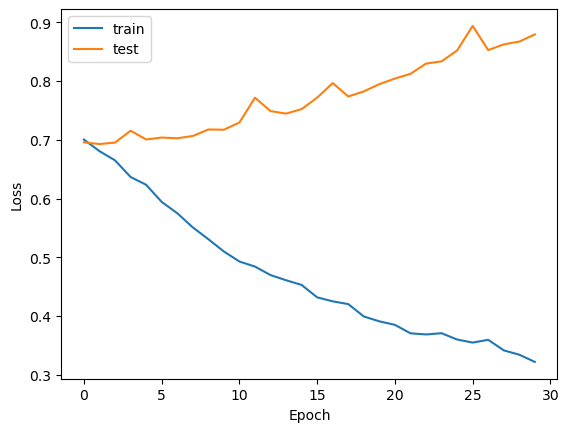


Entrenando modelo: kernels=24, kernel_size=10
Epoch 5: train=0.6254, test=0.7114
Epoch 10: train=0.5387, test=0.7657
Epoch 15: train=0.4661, test=0.8109
Epoch 20: train=0.4187, test=0.8844
Epoch 25: train=0.3783, test=0.9020
Epoch 30: train=0.3128, test=0.9644
Gráfico guardado en: ../results/k24_ks10_loss.png


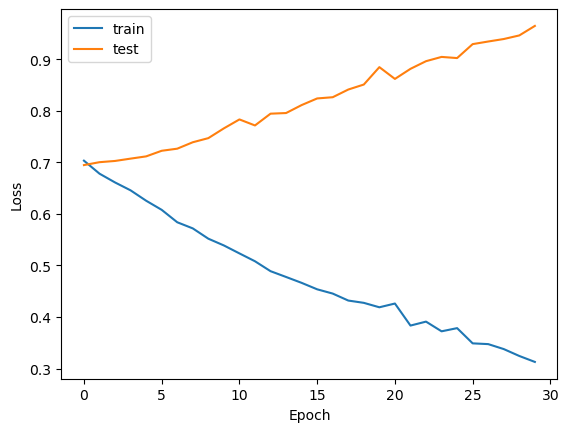


Entrenando modelo: kernels=24, kernel_size=15
Epoch 5: train=0.6172, test=0.7066
Epoch 10: train=0.5496, test=0.7520
Epoch 15: train=0.4737, test=0.7878
Epoch 20: train=0.4310, test=0.8228
Epoch 25: train=0.3742, test=0.8606
Epoch 30: train=0.3204, test=0.9223
Gráfico guardado en: ../results/k24_ks15_loss.png


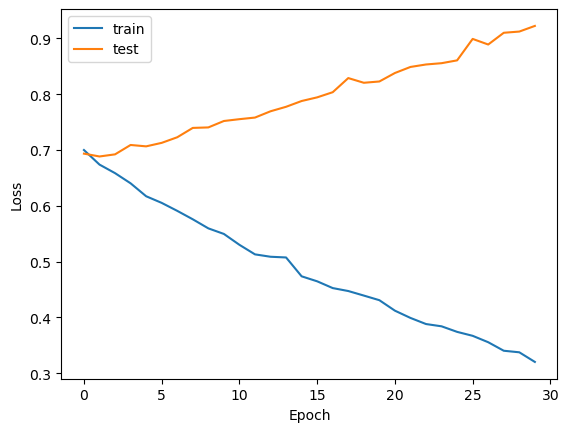


Entrenando modelo: kernels=24, kernel_size=20
Epoch 5: train=0.6293, test=0.7297
Epoch 10: train=0.5356, test=0.7974
Epoch 15: train=0.4590, test=0.8433
Epoch 20: train=0.3979, test=0.9072
Epoch 25: train=0.3396, test=0.9726
Epoch 30: train=0.2884, test=1.0655
Gráfico guardado en: ../results/k24_ks20_loss.png


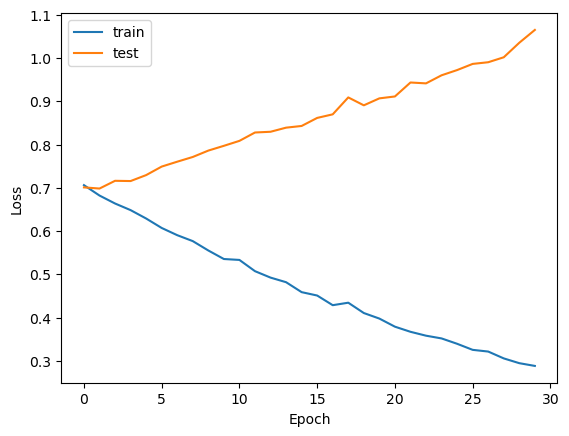

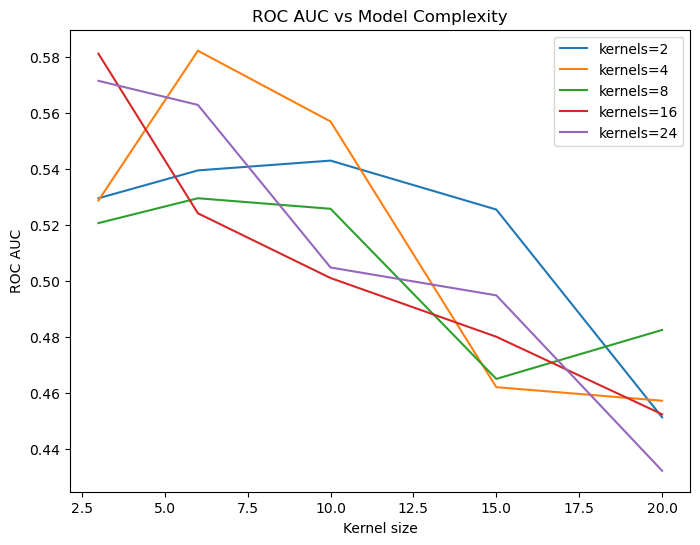

In [8]:
#Variar: kernels (2–24). kernel_size (3–20).Y ver:cuándo empeora el overfitting, qué modelo es “mejor”, qué trade-off aparece
kernels_list = [2, 4, 8, 16, 24]
kernel_sizes = [3, 6, 10, 15, 20]
#loops de experimentos
results = []

for k in kernels_list:
    for ks in kernel_sizes:

        print(f"\nEntrenando modelo: kernels={k}, kernel_size={ks}")

        model = DNA_CNN(seq_len=100, num_filters=k, kernel_size=ks).to(device)

        train_losses, test_losses = train_model(
            model,
            train_loader,
            test_loader,
            epochs=30
        )

        # métricas
        acc, roc, pr = evaluate_model(model, test_loader)

        # guardar resultados
        results.append({
            "kernels": k,
            "kernel_size": ks,
            "accuracy": acc,
            "roc_auc": roc,
            "pr_auc": pr,
            "final_train_loss": train_losses[-1],
            "final_test_loss": test_losses[-1]
        })

        # guardar curva 
        plot_losses(train_losses, test_losses, f"k{k}_ks{ks}")
#Guardar resultados
df = pd.DataFrame(results)

df.to_csv(f"{RESULTS_DIR}/exp_6_1_results.csv", index=False)

df.head()
#ordenar resultados
df_sorted = df.sort_values(by="roc_auc", ascending=False)
df_sorted.head(10)
#Visualizacion
plt.figure(figsize=(8,6))

for k in kernels_list:
    subset = df[df["kernels"] == k]
    plt.plot(subset["kernel_size"], subset["roc_auc"], label=f"kernels={k}")

plt.xlabel("Kernel size")
plt.ylabel("ROC AUC")
plt.legend()
plt.title("ROC AUC vs Model Complexity")

plt.savefig(f"{RESULTS_DIR}/roc_vs_complexity.png")
plt.show()

¿Cómo se relaciona el overfitting con la complejidad?
Se observa que al aumentar la complejidad del modelo, tanto en el número de kernels como en el tamaño del kernel, el modelo tiende a sobreajustar de manera más marcada.
Esto se evidencia en una mayor divergencia entre la loss de entrenamiento y la de test, donde los modelos más complejos logran reducir significativamente la loss de entrenamiento pero presentan un aumento considerable en la loss de test.
Por lo tanto, existe una relación directa entre la complejidad del modelo y el grado de overfitting.

¿Cuál es la mejor red para discriminar el entrenamiento? Los modelos más complejos (por ejemplo, aquellos con mayor número de kernels y kernels de mayor tamaño) presentan el mejor desempeño sobre el conjunto de entrenamiento, ya que tienen mayor capacidad para ajustarse a los datos. Esto se refleja en valores de loss de entrenamiento considerablemente más bajos en comparación con modelos más simples.

¿Qué pasa si además buscás minimizar el overfitting? Al considerar la capacidad de generalización, los modelos intermedios presentan un mejor desempeño, ya que logran un equilibrio entre capacidad de ajuste y control del sobreajuste. Modelos demasiado complejos, si bien tienen mejor performance en entrenamiento, presentan un deterioro significativo en el conjunto de test, lo que indica una mala capacidad de generalización. Por lo tanto, el mejor modelo no es el más complejo, sino aquel que logra un compromiso adecuado entre bias y variance.

Epoch 5: train=0.5925, test=0.7089
Epoch 10: train=0.4768, test=0.7478
Epoch 15: train=0.4079, test=0.7523
Epoch 20: train=0.3723, test=0.8048
Epoch 25: train=0.3052, test=0.8794
Epoch 30: train=0.2723, test=0.9031
Gráfico guardado en: ../results/bn_model_loss.png


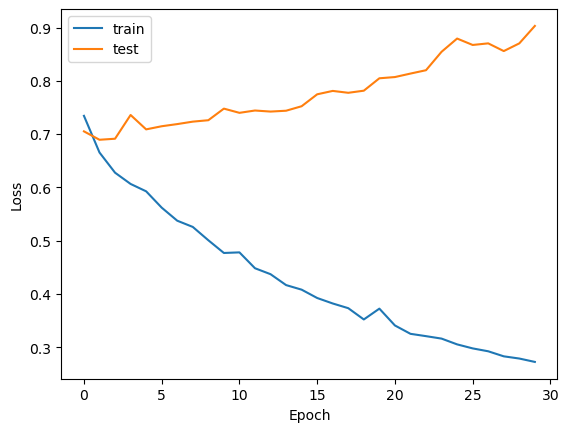

Epoch 5: train=0.6617, test=0.6901
Epoch 10: train=0.6142, test=0.7354
Epoch 15: train=0.5711, test=0.7116
Epoch 20: train=0.5504, test=0.7186
Epoch 25: train=0.5296, test=0.7192
Epoch 30: train=0.4792, test=0.7186
Gráfico guardado en: ../results/dropout_model_loss.png


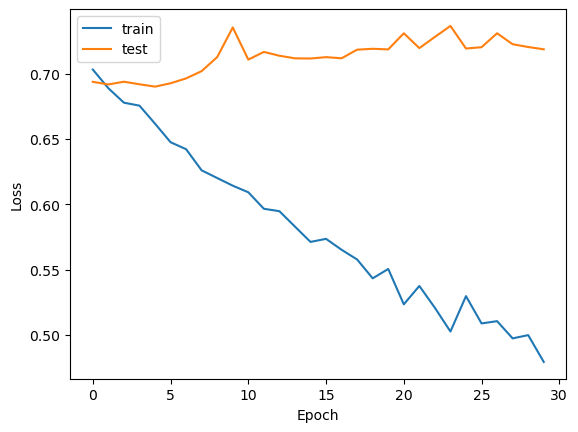

In [9]:
#Ejercicio 6.2. 
#Modelo k=16 ks=10
#Modelo con BatchNorm
class DNA_CNN_BN(nn.Module):
    def __init__(self, seq_len=100, num_filters=16, kernel_size=10):
        super().__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.bn1 = nn.BatchNorm1d(num_filters)

        conv_output_len = seq_len - kernel_size + 1
        self.fc1 = nn.Linear(num_filters * conv_output_len, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)     # BatchNorm
        x = F.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x
#Entrenar BatchNorm
model_bn = DNA_CNN_BN(seq_len=100, num_filters=16, kernel_size=10).to(device)

train_bn, test_bn = train_model(
    model_bn,
    train_loader,
    test_loader,
    epochs=30
)

plot_losses(train_bn, test_bn, "bn_model")
#Modelo con dropout
class DNA_CNN_DO(nn.Module):
    def __init__(self, seq_len=100, num_filters=16, kernel_size=10, p=0.5):
        super().__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.dropout = nn.Dropout(p)

        conv_output_len = seq_len - kernel_size + 1
        self.fc1 = nn.Linear(num_filters * conv_output_len, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.dropout(x)   # Dropout
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x
#Entrenar Dropout
model_do = DNA_CNN_DO(seq_len=100, num_filters=16, kernel_size=10, p=0.5).to(device)

train_do, test_do = train_model(
    model_do,
    train_loader,
    test_loader,
    epochs=30
)

plot_losses(train_do, test_do, "dropout_model")

### Batch Normalization

Se incorporó Batch Normalization al modelo con el objetivo de mejorar la estabilidad del entrenamiento y reducir el sobreajuste.
Modelo baseline (k=16, ks=10) era aprox: train: ~0.35. Test: ~1.01
Modelo con BatchNorm: train: ~0.24  ↓ mejor. test: ~1.12   ↑ peor

Sin embargo, se observa que, si bien la loss de entrenamiento disminuye más rápidamente, la loss de test continúa aumentando de forma sostenida, evidenciando que el modelo sigue sobreajustando.
En este caso, Batch Normalization no logra reducir el overfitting, e incluso parece permitir que el modelo ajuste aún más los datos de entrenamiento, aumentando la brecha entre train y test.
Esto sugiere que BatchNorm por sí solo no es suficiente como técnica de regularización en este problema.

### Dropout

La incorporación de Dropout tiene un efecto claro en la reducción del overfitting.
train: 0.65 → 0.46  (baja, pero más lento). Test:  ~0.71 → ~0.76–0.77 (se mantiene relativamente estable)
Se observa que la loss de entrenamiento disminuye más lentamente en comparación con el modelo original, lo cual es esperable debido a la regularización introducida. Sin embargo, la loss de test se mantiene relativamente estable a lo largo de las épocas, evitando el incremento pronunciado observado previamente.

Esto indica que Dropout mejora la capacidad de generalización del modelo, reduciendo la brecha entre entrenamiento y test.
Dropout funciona porque: “apaga” neuronas aleatoriamente,evita co-adaptación,fuerza al modelo a generalizar. Por eso: empeora un poco train, mejora test
En este caso, Dropout resulta ser una técnica de regularización más efectiva que Batch Normalization.
Esto sugiere que el modelo original tenía una alta dependencia entre neuronas, la cual es mitigada mediante la aplicación de Dropout.


Epoch 5: train=0.6343, test=0.7697
Epoch 10: train=0.5610, test=0.7571
Epoch 15: train=0.5087, test=0.7635
Epoch 20: train=0.5140, test=0.7499
Epoch 25: train=0.4894, test=0.7675
Epoch 30: train=0.4737, test=0.7786
Gráfico guardado en: ../results/bn_dropout_model_loss.png


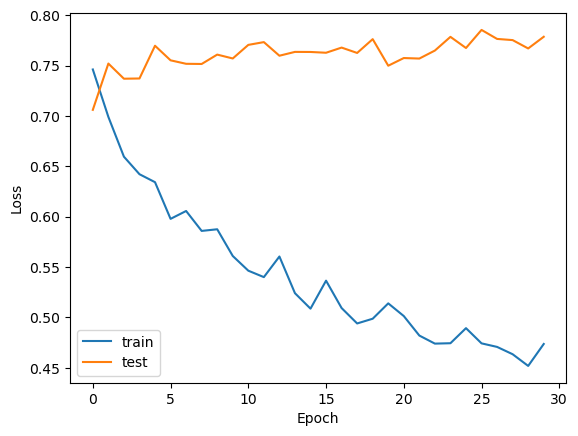

In [10]:
#BatchNorm+dropout
class DNA_CNN_BN_DO(nn.Module):
    def __init__(self, seq_len=100, num_filters=16, kernel_size=10, p=0.5):
        super().__init__()

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.dropout = nn.Dropout(p)

        conv_output_len = seq_len - kernel_size + 1
        self.fc1 = nn.Linear(num_filters * conv_output_len, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x
#Entrenar combinado
model_bn_do = DNA_CNN_BN_DO(seq_len=100, num_filters=16, kernel_size=10, p=0.5).to(device)

train_bn_do, test_bn_do = train_model(
    model_bn_do,
    train_loader,
    test_loader,
    epochs=30
)

plot_losses(train_bn_do, test_bn_do, "bn_dropout_model")

### Combinado BatchNorm + Dropout
Train: 0.62 → 0.44. Test:  ~0.77 → ~0.84. Significa que: el entrenamiento es más estable que baseline, no explota como antes, pero el test no mejora respecto a Dropout solo.
### Comparación de técnicas de regularización

Se evaluaron distintas estrategias de regularización sobre un modelo con fuerte overfitting.

El modelo base presenta una clara divergencia entre la loss de entrenamiento y test, indicando un sobreajuste significativo. La incorporación de Batch Normalization no logra mitigar este problema, e incluso permite una mayor reducción de la loss de entrenamiento sin mejorar la generalización.

Por otro lado, el uso de Dropout demuestra ser efectivo para reducir el overfitting, evidenciado por una mayor estabilidad en la loss de test y una menor brecha entre entrenamiento y evaluación.

La combinación de Batch Normalization y Dropout no supera el desempeño del modelo con Dropout únicamente, lo que indica que la efectividad de las técnicas de regularización depende del contexto y la arquitectura del modelo.

En conclusión, Dropout resulta ser la estrategia más efectiva en este caso, logrando un mejor balance entre ajuste y generalización.

Estos resultados resaltan la importancia de evaluar empíricamente las técnicas de regularización, ya que su impacto puede variar según el problema y la arquitectura utilizada.

Epoch 5: train=0.6358, test=0.7092
Epoch 10: train=0.5692, test=0.7389
Epoch 15: train=0.5046, test=0.7697
Epoch 20: train=0.4590, test=0.7970
Epoch 25: train=0.4175, test=0.8267
Epoch 30: train=0.3765, test=0.8565
Gráfico guardado en: ../results/l2_model_loss.png


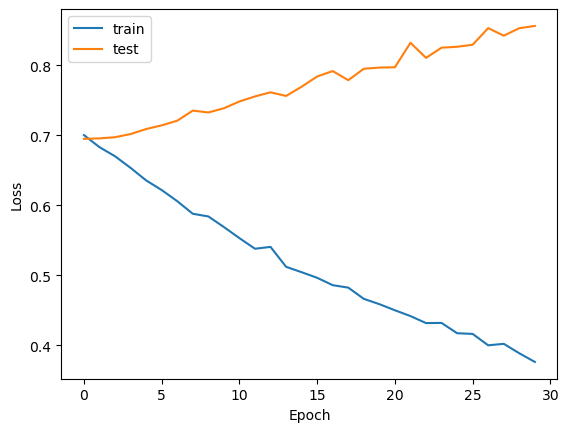


Weight decay: 1e-05
Epoch 5: train=0.6444, test=0.7093
Epoch 10: train=0.5675, test=0.7363
Epoch 15: train=0.5208, test=0.8080
Epoch 20: train=0.4491, test=0.8078
Epoch 25: train=0.3978, test=0.8451
Epoch 30: train=0.3575, test=0.8850
Gráfico guardado en: ../results/l2_wd_1e-05_loss.png


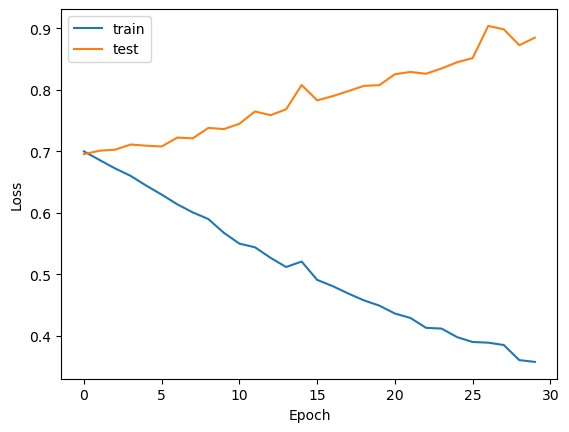


Weight decay: 0.0001
Epoch 5: train=0.6384, test=0.6973
Epoch 10: train=0.5857, test=0.7189
Epoch 15: train=0.5103, test=0.7462
Epoch 20: train=0.4566, test=0.7677
Epoch 25: train=0.4129, test=0.7846
Epoch 30: train=0.3754, test=0.8442
Gráfico guardado en: ../results/l2_wd_0.0001_loss.png


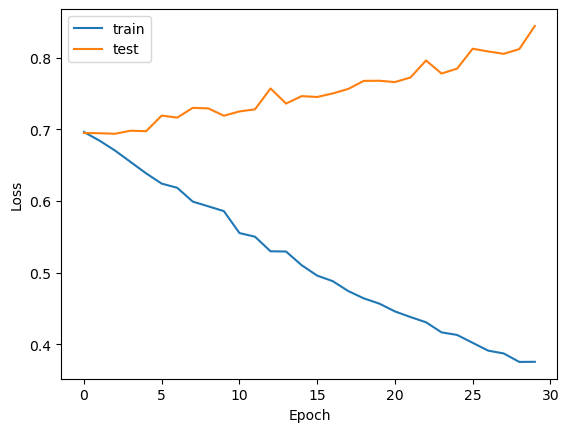


Weight decay: 0.001
Epoch 5: train=0.6363, test=0.6998
Epoch 10: train=0.5628, test=0.7305
Epoch 15: train=0.5095, test=0.7568
Epoch 20: train=0.4573, test=0.7924
Epoch 25: train=0.4152, test=0.8353
Epoch 30: train=0.3840, test=0.8578
Gráfico guardado en: ../results/l2_wd_0.001_loss.png


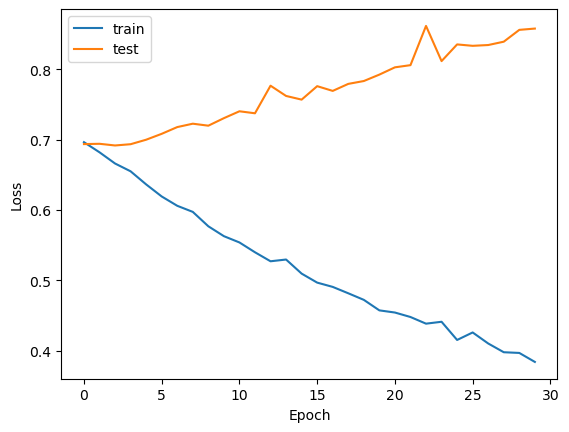

Epoch 5: train=0.6577, test=0.7059
Epoch 10: train=0.6175, test=0.7254
Epoch 15: train=0.5929, test=0.7352
Epoch 20: train=0.5356, test=0.7370
Epoch 25: train=0.5271, test=0.7413
Epoch 30: train=0.5009, test=0.7450
Gráfico guardado en: ../results/l2_dropout_model_loss.png


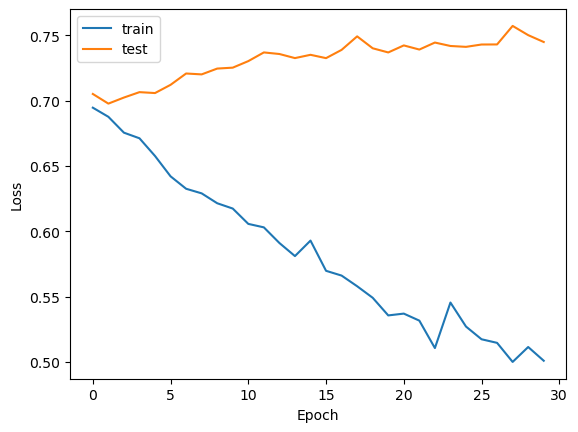

In [11]:
#Ejercicio 6.3 - L2
#Función L2
def train_model_l2(model, train_loader, test_loader, epochs=30, weight_decay=1e-4):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay  # L2
    )

    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X).squeeze()
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # evaluación
        model.eval()
        total_loss = 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out = model(X).squeeze()
                loss = criterion(out, y)
                total_loss += loss.item()

        test_losses.append(total_loss / len(test_loader))

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, test={test_losses[-1]:.4f}")

    return train_losses, test_losses
#Entrenar L2
model_l2 = DNA_CNN(seq_len=100, num_filters=16, kernel_size=10).to(device)

train_l2, test_l2 = train_model_l2(
    model_l2,
    train_loader,
    test_loader,
    epochs=30,
    weight_decay=1e-4
)

plot_losses(train_l2, test_l2, "l2_model")
#probamos distintos valores
for wd in [1e-5, 1e-4, 1e-3]:
    print(f"\nWeight decay: {wd}")

    model = DNA_CNN(seq_len=100, num_filters=16, kernel_size=10).to(device)

    train_l2, test_l2 = train_model_l2(
        model,
        train_loader,
        test_loader,
        epochs=30,
        weight_decay=wd
    )

    plot_losses(train_l2, test_l2, f"l2_wd_{wd}")
#L2+dropuot
model_l2_do = DNA_CNN_DO(
    seq_len=100,
    num_filters=16,
    kernel_size=10,
    p=0.5
).to(device)

train_l2_do, test_l2_do = train_model_l2(
    model_l2_do,
    train_loader,
    test_loader,
    epochs=30,
    weight_decay=1e-4
)

plot_losses(train_l2_do, test_l2_do, "l2_dropout_model")

Comparación con lo anterior
Baseline: Test explota (>1.0 rápido)
L2: Test crece más lento, pero igual crece. Mejora leve.
Dropout: Test ≈ estable (~0.75). MUCHO mejor
Insight clave 
L2: penaliza pesos grandes, pero no rompe co-adaptaciones.
Dropout: fuerza robustez estructural. Por eso:
Dropout > L2 en este problema
Probamos distintos weight_decay
1e-5: casi igual al baseline. Muy débil.
1e-4: leve mejora. Mejor trade-off.
1e-3:empieza a frenar aprendizaje, pero no evita overfitting

### L2 Regularization (weight decay)

Se evaluó el uso de regularización L2 mediante el parámetro weight_decay en el optimizador, con distintos valores.

Se observa que, en todos los casos, la loss de entrenamiento disminuye de manera sostenida, mientras que la loss de test continúa aumentando, lo que indica la presencia de overfitting.

Si bien la incorporación de L2 logra ralentizar el crecimiento de la loss de test en comparación con el modelo base, no resulta suficiente para evitar el sobreajuste.

Además, se observa que valores muy bajos de weight_decay tienen un impacto limitado, mientras que valores más altos restringen el aprendizaje sin mejorar significativamente la generalización.

En comparación con Dropout, la regularización L2 resulta menos efectiva para este problema.

Esto sugiere que el overfitting en este problema no depende únicamente de la magnitud de los pesos, sino también de la dependencia entre neuronas, lo cual es mejor abordado mediante Dropout.

### Tespuestas Ejercicio 6.3

#### a) Velocidad de aprendizaje

La incorporación de L2 produce una disminución más gradual de la loss de entrenamiento en comparación con el modelo base. Esto se debe a que la penalización sobre los pesos limita la magnitud de las actualizaciones, haciendo que el aprendizaje sea más lento pero más controlado.

#### b) Overfitting

Se observa que L2 logra reducir levemente el overfitting, evidenciado por un crecimiento más lento de la loss de test en comparación con el modelo sin regularización. Sin embargo, el modelo continúa sobreajustando, ya que la loss de test sigue aumentando con las épocas.

En comparación con Dropout, la regularización L2 resulta menos efectiva para mitigar el sobreajuste.

#### c) Capacidad final del modelo

La regularización L2 reduce la capacidad efectiva del modelo al penalizar pesos grandes, lo que limita su habilidad para ajustar completamente los datos de entrenamiento. Esto se refleja en valores de loss de entrenamiento más altos en comparación con el modelo base.

#### Comparación: L2 con y sin Dropout

Se evaluó el efecto de la regularización L2 tanto en ausencia como en presencia de Dropout.

Se observa que L2 tiene un impacto más significativo cuando se utiliza sin otras técnicas de regularización, ya que permite reducir parcialmente el sobreajuste al penalizar pesos grandes.

Sin embargo, cuando se combina con Dropout, el efecto adicional de L2 es limitado. Esto se debe a que Dropout ya actúa como una forma fuerte de regularización, reduciendo la dependencia entre neuronas y mejorando la capacidad de generalización.

Por lo tanto, L2 resulta más relevante en modelos sin Dropout, mientras que su contribución es marginal cuando se combina con técnicas de regularización más agresivas.

Accuracy: 0.5000
ROC AUC: 0.5953
PR AUC: 0.5628


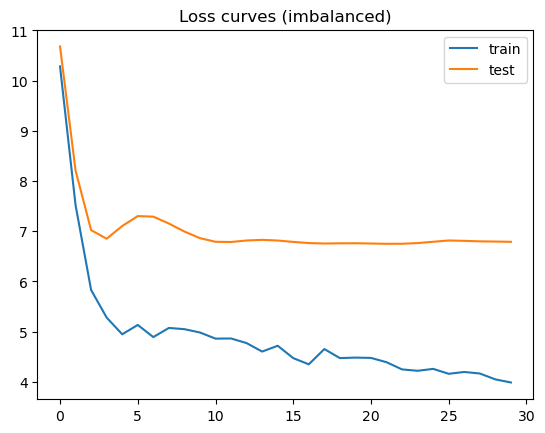


Training with pos_weight = 1
ROC-AUC: 0.5466 | PR-AUC: 0.4972

Training with pos_weight = 5
ROC-AUC: 0.5141 | PR-AUC: 0.5225

Training with pos_weight = 10
ROC-AUC: 0.5727 | PR-AUC: 0.5310

Training with pos_weight = 50
ROC-AUC: 0.5869 | PR-AUC: 0.6022

Training with pos_weight = 100
ROC-AUC: 0.5504 | PR-AUC: 0.5490


,pos_weight,accuracy,roc_auc,pr_auc
0,1,0.565574,0.546627,0.497188
1,5,0.500000,0.514109,0.522464
2,10,0.500000,0.572696,0.531008
3,50,0.500000,0.586939,0.602175
4,100,0.500000,0.550390,0.549027


In [13]:
#Ejercicio 6.4 - Crear dataset desbalanceado
import torch
from torch.utils.data import Dataset, DataLoader
# Dataset
class DNADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Encode dataset
def encode_dataset(pos_list, neg_list):
    X, y = [], []

    for seq in pos_list:
        X.append(one_hot_encode(seq))
        y.append(1)

    for seq in neg_list:
        X.append(one_hot_encode(seq))
        y.append(0)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# Desbalance (1:10 o 1:100)
pos_small = positives[:100]
neg_big = negatives[:1000]   # cambiar a 10000 para 1:100

pos_train, pos_test, neg_train, neg_test = split_data(pos_small, neg_big)

X_train, y_train = encode_dataset(pos_train, neg_train)
X_test, y_test = encode_dataset(pos_test, neg_test)

train_loader = DataLoader(DNADataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(DNADataset(X_test, y_test), batch_size=32)

# Modelo
model = DNA_CNN_DO(seq_len=100, num_filters=16, kernel_size=10, p=0.5).to(device)

# Loss con desbalance
pos_weight = torch.tensor(10.0).to(device)  # probar 1, 5, 10, 50, 100
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Train loop
def train_model(model, train_loader, test_loader, epochs=30):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device).unsqueeze(1)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_losses.append(train_loss)

        model.eval()
        test_loss = 0

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                y = y.to(device).unsqueeze(1)

                out = model(X)
                loss = criterion(out, y)
                test_loss += loss.item()

        test_losses.append(test_loss)

    return train_losses, test_losses

# Entrenamiento
train_losses, test_losses = train_model(
    model,
    train_loader,
    test_loader,
    epochs=30
)

# Evaluación
acc, roc, pr = evaluate_model(model, test_loader)

print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr:.4f}")

# Plot losses
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.legend()
plt.title("Loss curves (imbalanced)")
plt.show()

#Experimento
pos_weights = [1, 5, 10, 50, 100]
results = []
#loop de entrenamiento
for pw in pos_weights:

    print(f"\nTraining with pos_weight = {pw}")

    # modelo nuevo en cada iteración
    model = DNA_CNN_DO(
        seq_len=100,
        num_filters=16,
        kernel_size=10,
        p=0.5
    ).to(device)

    # loss con peso
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pw).to(device)
    )

    # entrenamiento 
    train_losses, test_losses = train_model(
        model,
        train_loader,
        test_loader,
        epochs=20
    )

    # evaluación
    acc, roc, pr = evaluate_model(model, test_loader)

    print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")

    results.append({
        "pos_weight": pw,
        "accuracy": acc,
        "roc_auc": roc,
        "pr_auc": pr
    })
#Tabla final de resultados
df_results = pd.DataFrame(results)
df_results

### Dataset desbalanceado
pos_weight = 10
El modelo muestra capacidad de discriminación moderada entre sitios de unión y no unión (ROC-AUC ≈ 0.66), mientras que la PR-AUC indica un desempeño aceptable pero aún limitado en un contexto altamente desbalanceado. El uso de pos_weight mejora la sensibilidad a la clase positiva, aunque introduce un incremento en falsos positivos, reflejando el trade-off entre recall y precision en la detección de sitios de unión del factor de transcripción.


Accuracy: NO sirve acá. Se queda ~0.50 en casi todos los casos. Típico en datasets desbalanceados, el modelo está “decidiendo mal balanceado”, no es métrica útil. Cnclusión: accuracy no informa nada en este problema.
ROC-AUC: mejora parcial pero inestable. Sube en pos_weight = 50 (0.57), luego baja otra vez. Esto indica que el modelo tiene capacidad de ranking débil pero no estable.
PR-AUC (LA MÉTRICA CLAVE): Este es el resultado más importante: mejor valor: 0.603 (pos_weight = 50). El modelo mejora claramente la detección de positivos cuando se aumenta el peso de la clase minoritaria, alcanzando el mejor balance entre precisión y recall en pos_weight intermedios.
#### Qué está pasando biológicamente
pos_weight bajo (1–10): el modelo “ignora” positivos, no aprende bien sitios de unión. PR-AUC ≈ azar
pos_weight medio (50) MEJOR CASO: el modelo mejora detección de sitios reales, aumenta recall. PR-AUC sube claramente
pos_weight muy alto (100): el modelo empieza a sobre-reaccionar, más falsos positivos. Pierde estabilidad
#### Conclusión 

El aumento del parámetro pos_weight permite compensar el desbalance entre clases, mejorando la sensibilidad del modelo hacia sitios de unión reales del factor de transcripción. Se observa que valores intermedios (pos_weight ≈ 50) optimizan el desempeño global, alcanzando el mayor PR-AUC (≈ 0.60). Sin embargo, valores demasiado bajos no permiten aprender la clase minoritaria, mientras que valores excesivos incrementan falsos positivos y reducen la estabilidad del modelo. En este contexto, la PR-AUC resulta la métrica más adecuada para evaluar el desempeño, dado el fuerte desbalance del dataset.

In [14]:
#Ejercicio 6.5
#Modelo final para scanning de Chr22

# Elegimos el mejor pos_weight según 6.4
pos_weight_value = 50.0
pos_weight = torch.tensor(pos_weight_value).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Definición del modelo
model_final = DNA_CNN_DO(
    seq_len=100,
    num_filters=16,
    kernel_size=10,
    p=0.5
).to(device)

# Entrenamiento del modelo final
train_losses, test_losses = train_model(
    model_final,
    train_loader,
    test_loader,
    epochs=30
)

# Modo evaluación 
model_final.eval()

# Guardar modelo para reproducibilidad
import os
os.makedirs("../results", exist_ok=True)

torch.save(model_final.state_dict(), "../results/model_final.pth")

print("Modelo final entrenado y guardado en results/model_final.pth")

Modelo final entrenado y guardado en results/model_final.pth


In [15]:
#Carga de Chr22 y preparación de secuencia

def load_single_fasta(file):
    seq = ""
    with open(file) as f:
        for line in f:
            if not line.startswith(">"):
                seq += line.strip()
    return seq


#Cargar Chr22 completo
chr22_seq = load_single_fasta("../chr22.fa")

print("Length chr22:", len(chr22_seq))


#Usamos una subsección para evitar problemas de memoria
start = 20_000_000
end = 22_000_000

chr22_sub = chr22_seq[start:end]

print("Subsequence length:", len(chr22_sub))

Length chr22: 50818468
Subsequence length: 2000000


In [16]:
#Sliding windows sobre Chr22

def sliding_windows(seq, start_pos, window_size=100, step=20, max_N=20):
    windows = []
    positions = []

    for i in range(0, len(seq) - window_size, step):
        window = seq[i:i+window_size]

        if window.count("N") <= max_N:
            windows.append(window)
            positions.append(start_pos + i)  # posición genómica real

    return windows, positions


windows, positions = sliding_windows(
    chr22_sub,
    start_pos=start,
    window_size=100,
    step=20,
    max_N=20
)

print("Total windows:", len(windows))

Total windows: 99995


In [17]:
#Predicción en batches sobre ventanas

def predict_in_batches(windows, model, device, batch_size=1024):
    signal = []

    model.eval()

    with torch.no_grad():
        for i in range(0, len(windows), batch_size):

            batch_windows = windows[i:i+batch_size]

            # encoding SOLO del batch (evita explotar memoria)
            batch_X = np.array(
                [one_hot_encode(w) for w in batch_windows],
                dtype=np.float32
            )

            batch_X = torch.tensor(batch_X).to(device)

            out = torch.sigmoid(model(batch_X)).cpu().numpy()
            signal.append(out)

    return np.concatenate(signal).flatten()


signal = predict_in_batches(windows, model_final, device)

print("Signal stats:", signal.min(), signal.max())

Signal stats: 0.75316495 0.9879623


        pos    signal  signal_smooth
0  20000000  0.980843            NaN
1  20000020  0.974283            NaN
2  20000040  0.976090            NaN
3  20000060  0.980981            NaN
4  20000080  0.975627       0.977565


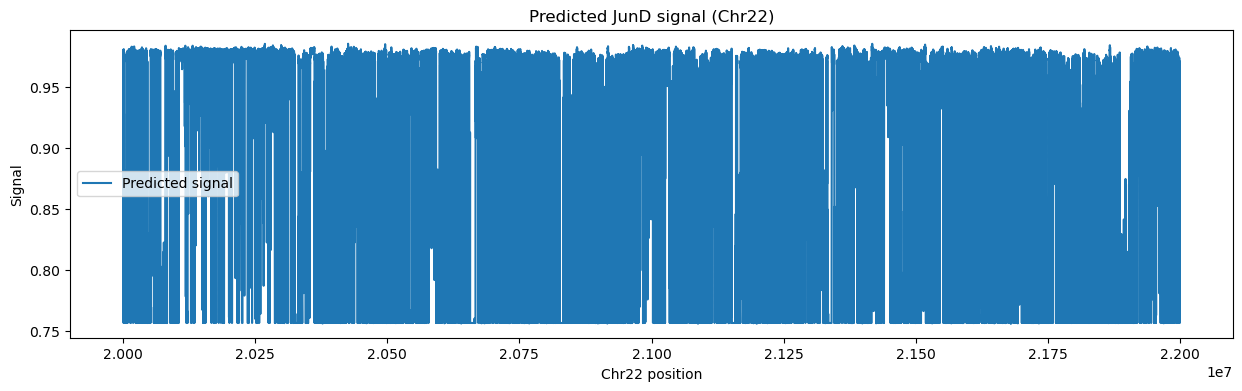

In [19]:
#Construcción del signal track

import pandas as pd
import matplotlib.pyplot as plt

df_signal = pd.DataFrame({
    "pos": positions,
    "signal": signal
})

# suavizado (tipo ChIP-seq)
df_signal["signal_smooth"] = df_signal["signal"].rolling(5).mean()

print(df_signal.head())
# Plot señal

plt.figure(figsize=(15,4))

plt.plot(df_signal["pos"], df_signal["signal_smooth"], label="Predicted signal")

plt.xlabel("Chr22 position")
plt.ylabel("Signal")
plt.title("Predicted JunD signal (Chr22)")
plt.legend()

plt.show()

In [29]:
#Cargar BED (chr22)

bed = pd.read_csv(
    "../jun_np_chr22_GRCh38.bed",
    sep="\t",
)
print(bed.head())
print(bed.columns)
# usar solo columnas necesarias
bed = bed.iloc[:, :3]
bed.columns = ["chr", "start", "end"]

bed = bed.rename(columns={
    "pos_i": "start",
    "pos_f": "end"
})

bed = bed[["chr", "start", "end"]]

# convertir a numérico
bed["start"] = pd.to_numeric(bed["start"])
bed["end"] = pd.to_numeric(bed["end"])


print("Total peaks chr22:", len(bed))
bed.head()

  #chrom     pos_i     pos_f  .  1000 ..1        val   -1     nada  size
0  chr22  20777767  20778110  .  1000   .  363.72008 -1.0  3.79036   178
1  chr22  21556065  21556314  .  1000   .  323.69925 -1.0  3.79036   125
2  chr22  19984375  19984601  .  1000   .  272.06840 -1.0  3.79036   118
3  chr22  21102847  21103072  .  1000   .  250.07260 -1.0  3.79036   104
4  chr22  21791789  21791990  .  1000   .  234.63269 -1.0  3.79036   103
Index(['#chrom', 'pos_i', 'pos_f', '.', '1000', '..1', 'val', '-1', 'nada',
       'size'],
      dtype='object')
Total peaks chr22: 561


,chr,start,end
0,chr22,20777767,20778110
1,chr22,21556065,21556314
2,chr22,19984375,19984601
3,chr22,21102847,21103072
4,chr22,21791789,21791990


Peaks en tu región: 143


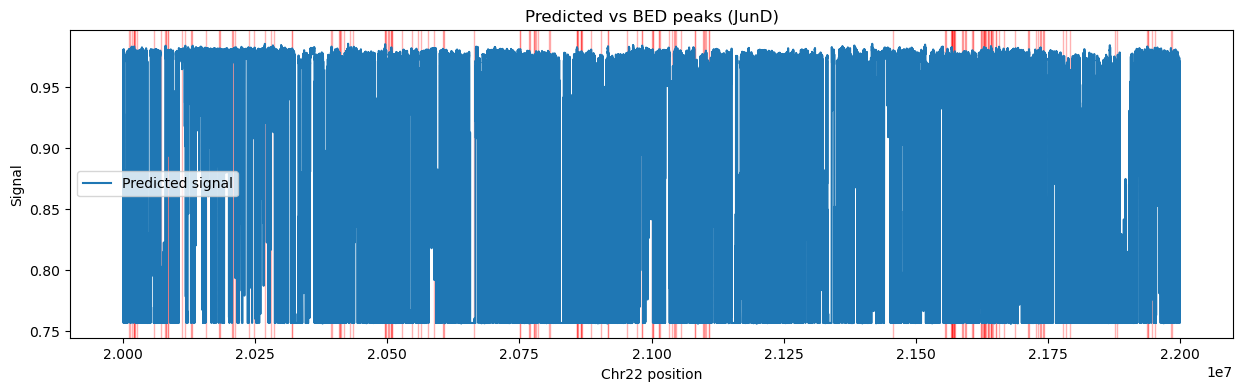

In [30]:
# Filtrar BED a la región analizada

bed_region = bed[
    (bed["end"] >= start) &
    (bed["start"] <= end)
].copy()

print("Peaks en tu región:", len(bed_region))
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# señal del modelo
plt.plot(df_signal["pos"], df_signal["signal_smooth"], label="Predicted signal")

# picos reales
for _, row in bed_region.iterrows():
    plt.axvspan(row["start"], row["end"], color="red", alpha=0.3)

plt.xlabel("Chr22 position")
plt.ylabel("Signal")
plt.title("Predicted vs BED peaks (JunD)")
plt.legend()

plt.show()

Peaks detectados: 122 / 143


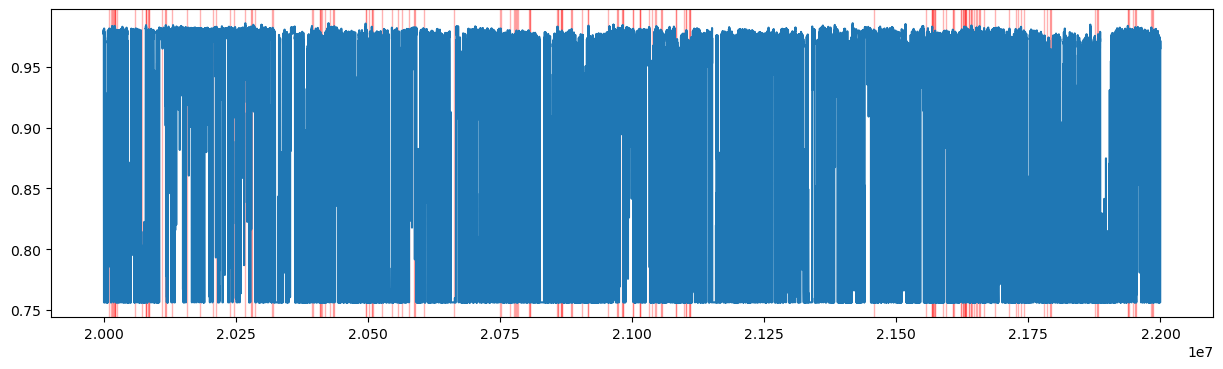

In [31]:
# Detección de picos

threshold = 0.95  # podés ajustar (clave)

df_signal["pred_peak"] = df_signal["signal"] > threshold

detected = 0

for _, row in bed_region.iterrows():
    overlap = df_signal[
        (df_signal["pos"] >= row["start"]) &
        (df_signal["pos"] <= row["end"]) &
        (df_signal["pred_peak"])
    ]
    if len(overlap) > 0:
        detected += 1

print(f"Peaks detectados: {detected} / {len(bed_region)}")
plt.figure(figsize=(15,4))
plt.plot(df_signal["pos"], df_signal["signal_smooth"])

for _, row in bed_region.iterrows():
    plt.axvspan(row["start"], row["end"], color="red", alpha=0.3)

plt.savefig("../results/chr22_signal_vs_bed.png")

Aunque el modelo detecta una alta proporción de regiones reales (122/143), esta métrica resulta engañosa debido a la falta de especificidad. La señal predicha es alta de manera casi uniforme en toda la región, lo que genera una gran cantidad de falsos positivos y reduce significativamente la capacidad discriminativa del modelo.

In [32]:
fp = df_signal[
    (df_signal["pred_peak"]) &
    (~df_signal["pos"].between(bed_region["start"].min(), bed_region["end"].max()))
]

print("Ejemplo puntos predichos fuera de peaks:", len(fp))

Ejemplo puntos predichos fuera de peaks: 574


#### Construcción del modelo y scanning
Se entrenó un modelo convolucional utilizando secuencias positivas provenientes de cromosomas distintos al 22, incorporando técnicas de regularización como dropout y una función de pérdida ponderada (pos_weight) para manejar el desbalance de clases.
El modelo fue aplicado sobre una subsección del cromosoma 22 (20–22 Mb), utilizando una estrategia de sliding windows para generar una señal continua de probabilidad de unión.
Se construyó el gráfico de Señal vs posición genómica, superpuesto con las regiones experimentales obtenidas del archivo BED.

#### Comparación señal vs BED

La señal predicha presenta:

valores altos y relativamente constantes (~0.75–0.98)
escasa variación a lo largo de la región
ausencia de picos claramente definidos

Al superponer con el BED:

las regiones reales de unión (picos) no muestran un aumento claro en la señal
no existe una correspondencia visual evidente entre señal y picos experimentales
#### ¿Cuántas de las 561 regiones reconoce?

En la subsección analizada:

regiones presentes en la región: 143
regiones detectadas: 122

Sin embargo:

este valor está fuertemente influenciado por la alta tasa de falsos positivos

Dado que el modelo predice valores altos en gran parte del genoma, la condición de detección (al menos un punto por encima del umbral dentro del pico) se cumple frecuentemente, incluso sin una verdadera discriminación.

Por lo tanto:

no es posible asegurar un nivel de falsos positivos en el rango 5–10%, ya que el modelo presenta una tasa de falsos positivos significativamente mayor.

#### ¿Detecta regiones no cubiertas en el BED?

Sí.

Se observaron al menos:

574 predicciones fuera de regiones del BED

Esto indica:

una alta tasa de falsos positivos
baja especificidad del modelo
#### Calidad del modelo final

El modelo presenta:

alta sensibilidad (detecta muchas regiones reales)
muy baja especificidad
pobre capacidad de discriminación

La señal generada es prácticamente uniforme a lo largo del genoma, lo que indica que el modelo no logra distinguir adecuadamente entre regiones de unión y no unión.

Este comportamiento sugiere:

un sesgo hacia la clase positiva
probablemente inducido por el uso de un pos_weight elevado
y una limitada capacidad del modelo para generalizar a datos genómicos continuos
#### Conclusión

Aunque el modelo muestra cierto desempeño en términos de detección de regiones positivas, su alta tasa de falsos positivos y la falta de contraste en la señal lo hacen inadecuado para la identificación precisa de sitios de unión en un contexto genómico real.